<a href="https://colab.research.google.com/github/nei0017/Natasha_INFO4670.401_Spring2026/blob/main/INFO4670_Assignment_SMS_Spam_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [1]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')


Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
> Blocking a real message is more costly because a user might miss out on important information

**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
> Precision measures the accuracy of positives which minimizes the number of real messages that are flagged as spam.

**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
> the accuracy would be 87%, which wouldn't really catch any spam.


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [2]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)



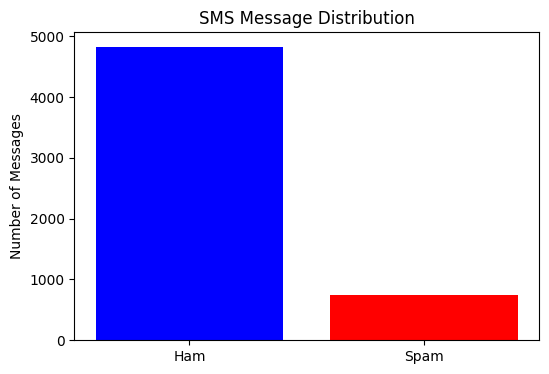

Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%


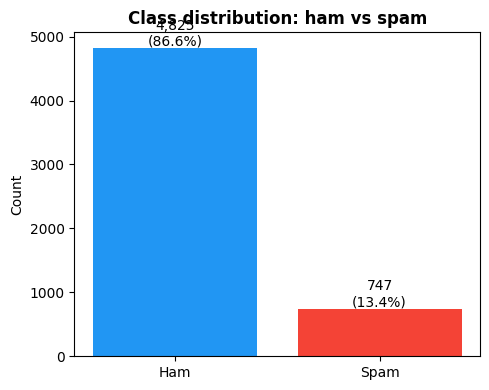

In [3]:
# Write your code here
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()
#prints count and percentage
counts = raw['label'].value_counts()
percent = raw['label'].value_counts(normalize=True) * 100

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1-spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

#plot bar chart
plt.figure(figsize=(6, 4))
plt.bar(['Ham', 'Spam'], counts, color=['blue', 'red'])
plt.title('SMS Message Distribution')
plt.ylabel('Number of Messages')
plt.show()

accuracy_dummy = percent['ham'] / 100
recall_dummy = 0.0
f1_dummy = 0.0

# Prove the accuracy trap with a dummy model
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)
print(f'Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [4]:
#print('=== SPAM examples ===')
#for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    #print(f'{i}. {msg[:130]}')
    #print()

print("=== SPAM EXAMPLES ===")
spam_samples = raw[raw['label'] == 'spam']['message'].head(5)
for i, msg in enumerate(spam_samples, 1):
    print(f"{i}. {msg[:130]}...")


print("=== HAM EXAMPLES ===")
ham_samples = raw[raw['label'] == 'ham']['message'].head(5)
for i, msg in enumerate(ham_samples, 1):

    print(f"{i}. {msg[:130]}...")

#print('=== HAM examples ===')
#for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    #print(f'{i}. {msg[:130]}')
    #print()


=== SPAM EXAMPLES ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's ...
2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s...
3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code ...
4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat...
5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL ...
=== HAM EXAMPLES ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat......
2. Ok lar... Joking wif u oni......
3. U dun say so early hor... U c already then say......
4. Nah I don't think he goes to usf, he lives around here thou

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


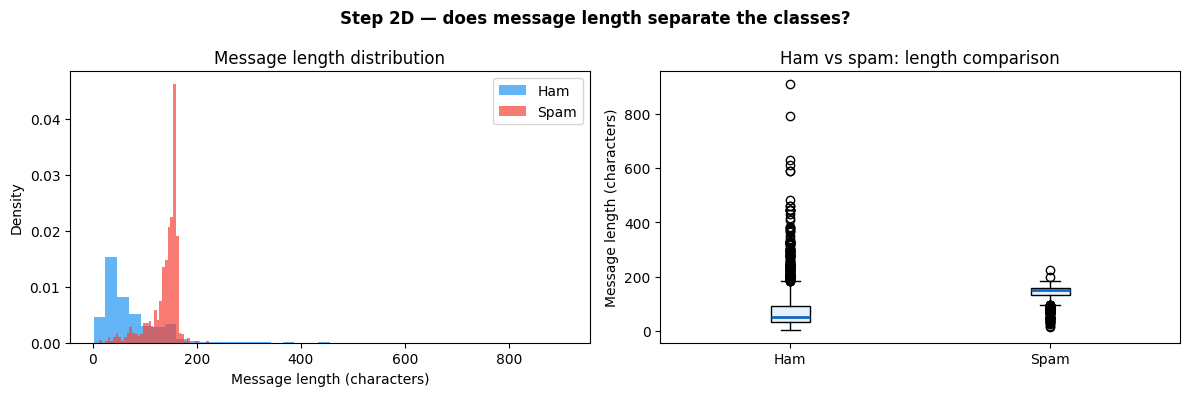

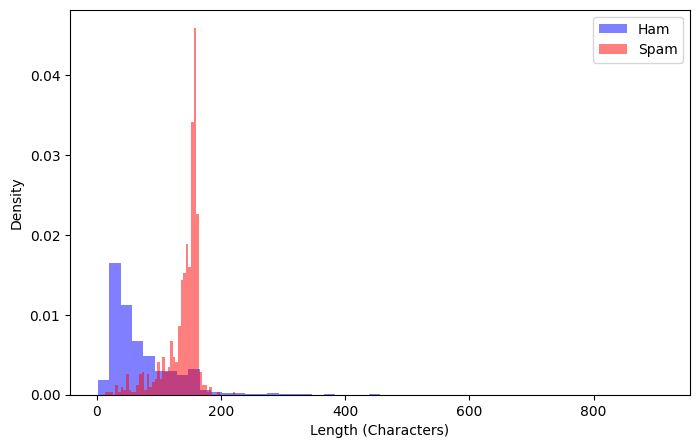

In [7]:
raw['msg_length'] = raw['message'].str.len()

hamlength_avg = raw[raw['label'] == 'ham']['msg_length'].mean()
spamlength_avg = raw[raw['label'] == 'spam']['msg_length'].mean()
print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(raw[raw['spam']==0]['msg_length'], bins=50, alpha=0.5, label='Ham', color='blue', density=True)
plt.hist(raw[raw['spam']==1]['msg_length'], bins=50, alpha=0.5, label='Spam', color='red', density=True)
plt.xlabel('Length (Characters)')
plt.ylabel('Density')
plt.legend()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [8]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [10]:
# Write your code here

def build_features_v2(df):
    d = build_features(df)   # keeps all 4 starter features
    msg = d['message'].str.lower()

    # --- Feature 5: add your first feature here ---
    # d['feature_name'] = msg.str.contains(r'...', regex=True).astype(int)
    d['has_exclamations'] = msg.str.contains(
        r'!!|!!!', regex=True).astype(int)
    # --- Feature 6: add your second feature here ---
    # d['feature_name'] = ...
    d['has_link'] = msg.str.contains(
        r'http|https|www|\.com|\.net', case=False,
        regex=True).astype(int)


    return d

df = build_features_v2(raw)

# Collect all feature column names — DO NOT delete this line
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)
for feat in feature_cols:
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            34.9%    6.4%  +28.5%
is_long                76.8%   14.2%  +62.7%
has_exclamations        1.5%    1.4%   +0.1%
has_link               16.6%    0.4%  +16.2%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


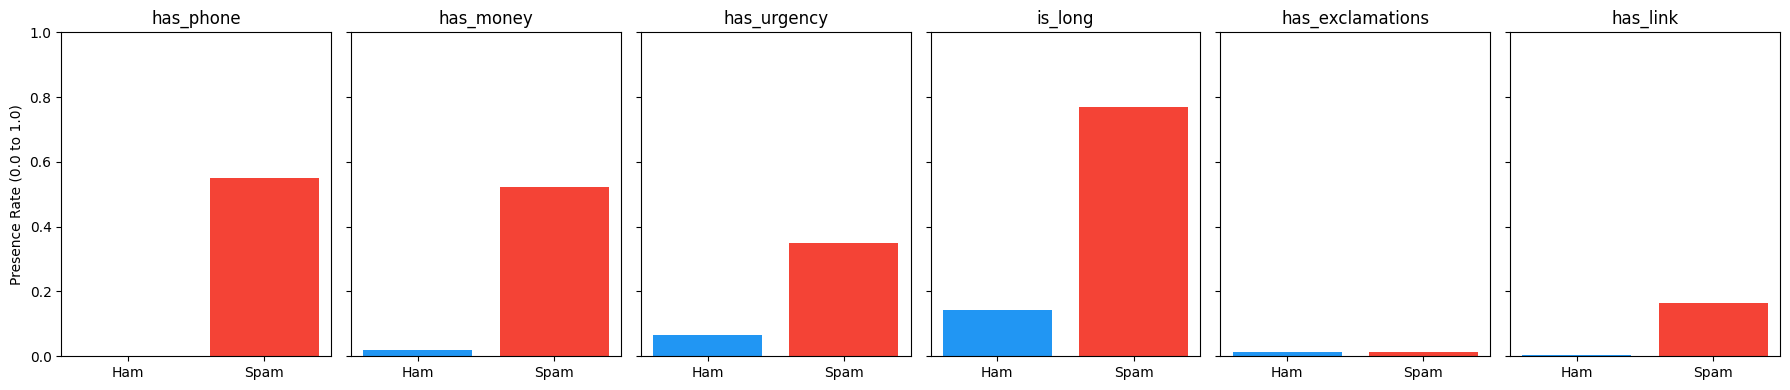

In [19]:
# Write your code here
import matplotlib.pyplot as plt
n_features = len(feature_cols)
fig, axes = plt.subplots(1, n_features, figsize=(3 * n_features, 4), sharey=True)

for i, ft in enumerate(feature_cols):
  spam_rate = df[df['spam'] == 1][ft].mean()
  ham_rate = df[df['spam'] == 0][ft].mean()
  axes[i].bar(['Ham', 'Spam'], [ham_rate, spam_rate], color=['#2196F3', '#F44336'])

  axes[i].set_title(ft)
  axes[i].set_ylim(0, 1)
  if i == 0:
      axes[i].set_ylabel('Presence Rate (0.0 to 1.0)')
plt.tight_layout()
plt.show()


### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 — has_exclamations
> This feature records the use of multiple exclamation points. This is a useful signal because most spam uses a lot of energy to get users excited or to create urgency.

*Feature 2 — has_link
> This feature identifies the presence of URLs or web addresses. I expected this to be highly effective because the goal of most spam is to redirect the user to a website for phishing

**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
> The feature in the gap column with the largest gap is is_long. A large gap means that the feature is a very strong identifier. When a Decision Tree selects its Root Node, it looks for the feature that results in the highest information gain which measures the amount of disorder.

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
> "FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok!"
has_money fails: This feature looks for words like win, cash, prize, or claim. Even though the message starts with "FreeMsg," it doesn't offer a financial reward or prize, so it avoids the "money" filter.

has_phone and has_link fail: The message asks for a text reply ("Tb ok!") rather than providing a 10-digit phone number to call or a website link (.com, http) to click.


---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [21]:
# Write your code here
from sklearn.model_selection import train_test_split
X = df[feature_cols].values
y = df['spam'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Testing set:  {len(X_test)} samples")
print("-" * 30)

print(f"Spam rate in Training: {y_train.mean():.1%}")
print(f"Spam rate in Testing:  {y_test.mean():.1%}")

Training set: 4179 samples
Testing set:  1393 samples
------------------------------
Spam rate in Training: 13.4%
Spam rate in Testing:  13.4%


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
> To ensure that the proportion of spam to ham remains the same in both the training and testing sets as it is in the original dataset. a random split might accidentally put almost all the spam messages into the training set and very few into the test set whcih could be unreliable.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
> a single 75/25 split might accidentally put the hardest or easiest examples all into the test set just by chance. This would give you a misleading accuracy score. Cross-validation solves this by rotating the test set through the entire dataset multiple times.


---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Number of leaves in the tree: 14
------------------------------
Decision Tree Rules:
|--- is_long <= 0.50
|   |--- has_phone <= 0.50
|   |   |--- has_money <= 0.50
|   |   |   |--- has_link <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_link >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_money >  0.50
|   |   |   |--- has_link <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_link >  0.50
|   |   |   |   |--- class: 1
|   |--- has_phone >  0.50
|   |   |--- has_urgency <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_urgency >  0.50
|   |   |   |--- class: 1
|--- is_long >  0.50
|   |--- has_phone <= 0.50
|   |   |--- has_money <= 0.50
|   |   |   |--- has_link <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_link >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_money >  0.50
|   |   |   |--- has_urgency <= 0.50
|   |   |   |   |--- clas

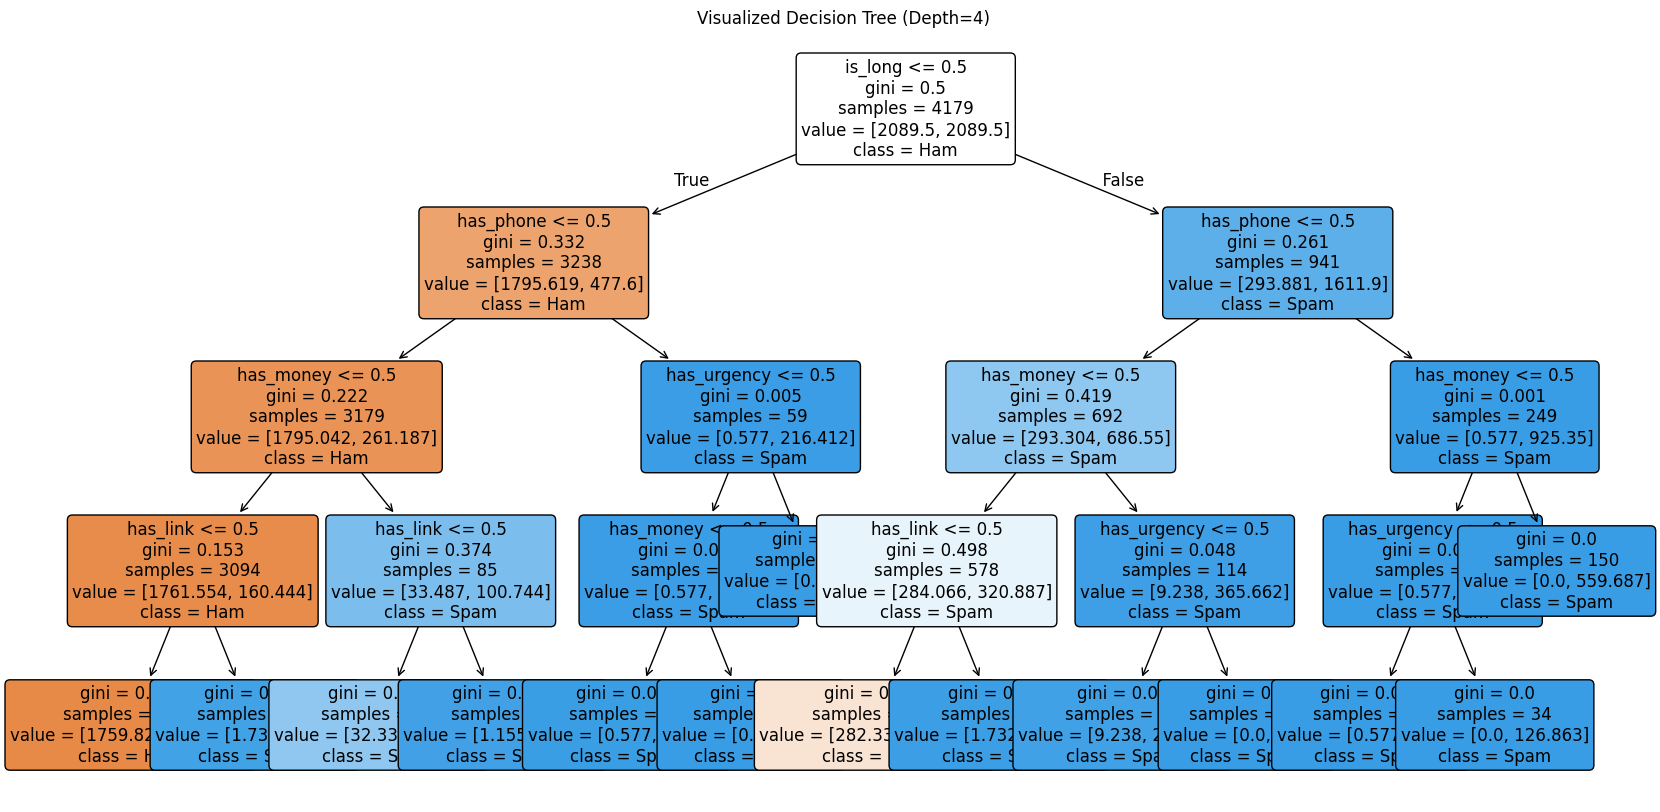

In [23]:
# Write your code here
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import matplotlib.pyplot as plt

dt_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    class_weight='balanced'
)
dt_model.fit(X_train, y_train)
print(f"Number of leaves in the tree: {dt_model.get_n_leaves()}")
print("-" * 30)

tree_rules = export_text(dt_model, feature_names=feature_cols)
print("Decision Tree Rules:")
print(tree_rules)
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=feature_cols,
    class_names=['Ham', 'Spam'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Visualized Decision Tree (Depth=4)")
plt.show()

### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


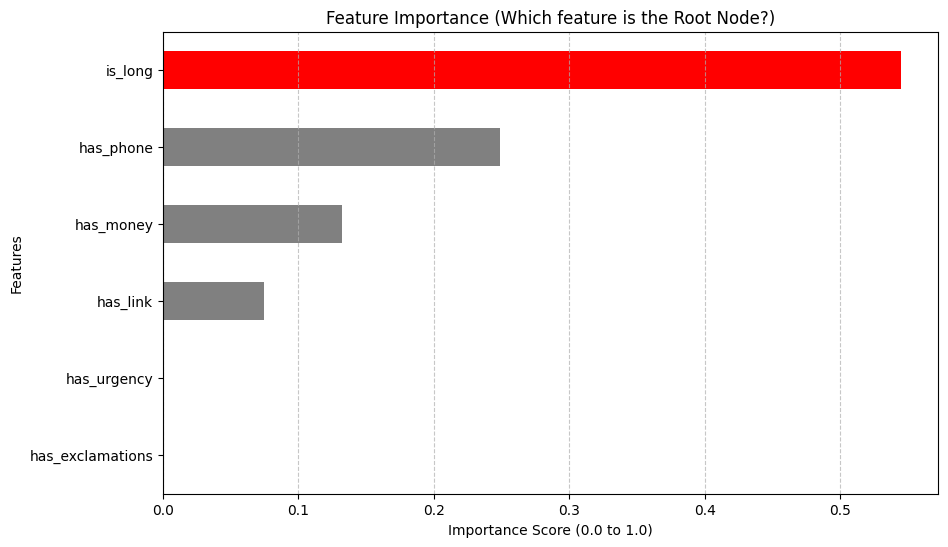

The most important feature (Root Node) is: is_long


In [24]:
# Write your code here
import pandas as pd
import matplotlib.pyplot as plt

importances = dt_model.feature_importances_

# 2. Create a pandas Series for easy plotting
feat_importances = pd.Series(importances, index=feature_cols)

# 3. Sort them so the most important is at the top
feat_importances = feat_importances.sort_values()

# 4. Create the color list (Gray for all, Red for the highest)
# Since we sorted them, the last item [-1] is the highest
colors = ['gray'] * len(feat_importances)
colors[-1] = 'red'

# 5. Plot the horizontal bar chart
plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color=colors)

plt.title('Feature Importance (Which feature is the Root Node?)')
plt.xlabel('Importance Score (0.0 to 1.0)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 6. Print the top feature for clarity
print(f"The most important feature (Root Node) is: {feat_importances.idxmax()}")

### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


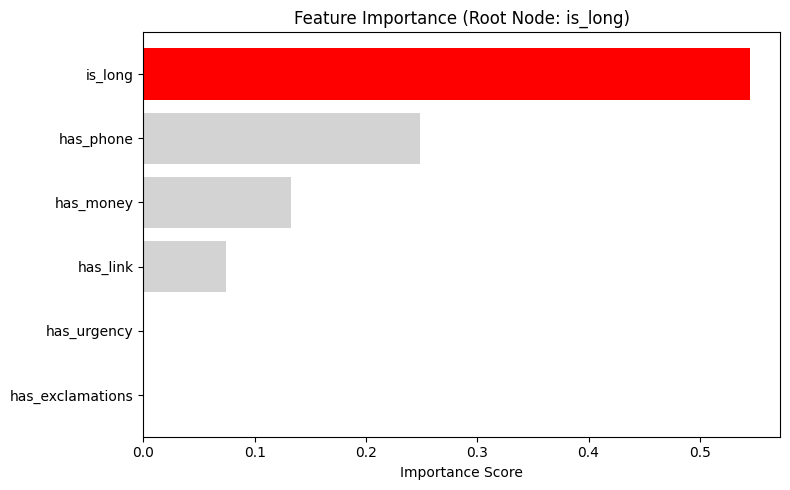

The Decision Tree starts splitting at: is_long


In [25]:
import matplotlib.pyplot as plt
import pandas as pd

feat_importances = pd.Series(dt_model.feature_importances_, index=feature_cols).sort_values()
root_node = feat_importances.idxmax()
colors = ['red' if x == root_node else 'lightgray' for x in feat_importances.index]

plt.figure(figsize=(8, 5))
feat_importances.plot(kind='barh', color=colors, width=0.8)

plt.title(f'Feature Importance (Root Node: {root_node})', fontsize=12)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(f"The Decision Tree starts splitting at: {root_node}")

### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [26]:
# Write your code here
from sklearn.naive_bayes import BernoulliNB
nb_model = BernoulliNB()

nb_model.fit(X_train, y_train)

print("Bernoulli Naive Bayes training complete.")


Bernoulli Naive Bayes training complete.


---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


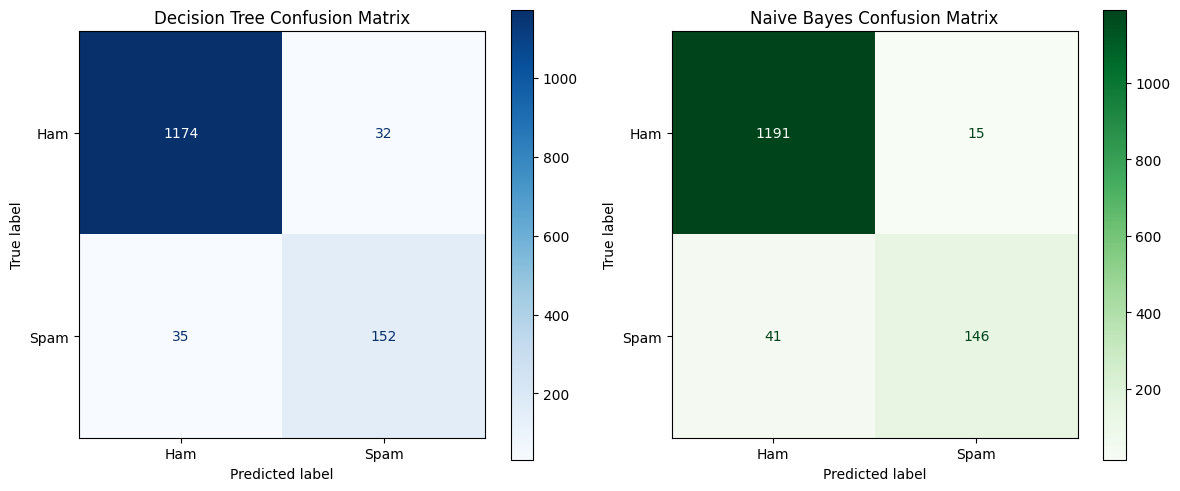

--- Decision Tree Results ---
True Positives (Spam caught): 152
False Positives (Ham blocked): 32
False Negatives (Spam missed): 35
True Negatives (Ham allowed):  1174

--- Naive Bayes Results ---
True Positives (Spam caught): 146
False Positives (Ham blocked): 15
False Negatives (Spam missed): 41
True Negatives (Ham allowed):  1191



In [27]:
# Write your code here
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_dt = dt_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['Ham', 'Spam'],
    cmap='Blues', ax=ax[0]
)
ax[0].set_title('Decision Tree Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb,
    display_labels=['Ham', 'Spam'],
    cmap='Greens', ax=ax[1]
)
ax[1].set_title('Naive Bayes Confusion Matrix')

plt.tight_layout()
plt.show()

for name, y_pred in [("Decision Tree", y_pred_dt), ("Naive Bayes", y_pred_nb)]:
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f"--- {name} Results ---")
    print(f"True Positives (Spam caught): {tp}")
    print(f"False Positives (Ham blocked): {fp}")
    print(f"False Negatives (Spam missed): {fn}")
    print(f"True Negatives (Ham allowed):  {tn}")
    print()

### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


--- Final Model Performance ---
               Accuracy  Precision  Recall  F1-Score
Model                                               
Decision Tree     0.952      0.826   0.813     0.819
Naive Bayes       0.960      0.907   0.781     0.839


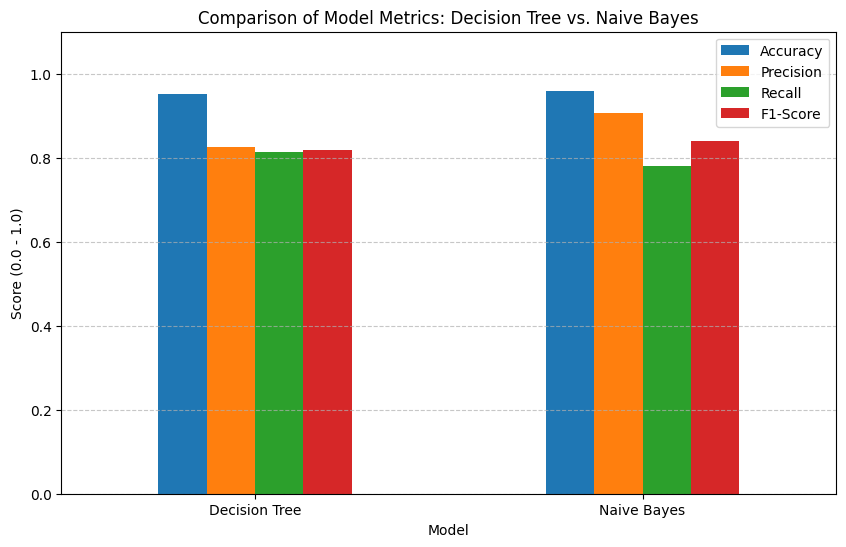

In [28]:
# Write your code here
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

models = [
    ("Decision Tree", y_test, y_pred_dt),
    ("Naive Bayes", y_test, y_pred_nb)
]

results_list = []

for name, actual, predicted in models:
    results_list.append({
        'Model': name,
        'Accuracy': accuracy_score(actual, predicted),
        'Precision': precision_score(actual, predicted),
        'Recall': recall_score(actual, predicted),
        'F1-Score': f1_score(actual, predicted)
    })

performance_df = pd.DataFrame(results_list).set_index('Model')
print("--- Final Model Performance ---")
print(performance_df.round(3))

performance_df.plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('Comparison of Model Metrics: Decision Tree vs. Naive Bayes')
plt.ylabel('Score (0.0 - 1.0)')
plt.ylim(0, 1.1)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [29]:
# Write your code here
from sklearn.model_selection import StratifiedKFold, cross_val_score
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_to_test = {
    "Decision Tree": dt_model,
    "Naive Bayes": nb_model
}

print("--- 5-Fold Cross-Validation (F1-Score) ---")

for name, model in models_to_test.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='f1')
    print(f"{name:15} | Mean F1: {scores.mean():.3f} (+/- {scores.std():.3f})")

--- 5-Fold Cross-Validation (F1-Score) ---
Decision Tree   | Mean F1: 0.837 (+/- 0.025)
Naive Bayes     | Mean F1: 0.851 (+/- 0.023)


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
> True Positives (Spam caught): 152

False Negatives (Spam missed): 35

False Positives (Legitimate messages wrongly blocked): 32

*Naive Bayes:*
> True Positives (Spam caught): 146

False Negatives (Spam missed): 41

False Positives (Legitimate messages wrongly blocked): 15

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
> I chose the F1-Score as my primary metric because it provides a balanced measure of a model's ability to catch spam without over-blocking legitimate mail. My cross-validation results in Step 6C likely confirm this, showing that Naive Bayes is more consistent and less prone to the "aggressive" errors seen in the Decision Tree.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model.

*Your memo:*
> I recommend deploying the Naive Bayes model for our SMS filtering service. While the Decision Tree catches slightly more spam, the Naive Bayes model is far superior at protecting legitimate user communication, resulting in only 15 False Positives compared to the Tree's 32. In a mobile carrier environment, accidentally blocking a customer's real message is a much worse user experience than letting a single spam text through. A current weakness of this model is its lower Recall

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
> has_phone: Modern spam often uses "click-to-chat" links or obfuscated URLs rather than a literal 10-digit phone number. Since scammers want to avoid automated detection of phone patterns, this feature would likely fail to flag many modern phishing attempts.

is_long: Many modern "smishing" attacks are extremely brief, such as a short "Your package is pending: link" message. Because these are roughly the same length as a normal text, the is_long feature would not see them as an anomaly, allowing them to pass through the filter undetected.
